# Dfs2

A dfs2 file is also called a grid series file. Values in a dfs2 file are
‘element based’, i.e. values are defined in the centre of each grid
cell.

In [1]:
import mikeio
ds = mikeio.read("../data/gebco_sound.dfs2")
ds

<mikeio.Dataset>
dims: (time:1, y:264, x:216)
time: 2020-05-15 11:04:52 (time-invariant)
geometry: Grid2D (ny=264, nx=216)
items:
  0:  Elevation <Total Water Depth> (meter)

## Subset in space

The most convenient way to subset in space is to use the `sel` method,
which returns a new (smaller) dataset, which can be further processed or
written to disk using the `to_dfs` method.

In [2]:
ds.geometry

<mikeio.Grid2D>
x: [12.2, 12.21, ..., 13.1] (nx=216, dx=0.004167)
y: [55.2, 55.21, ..., 56.3] (ny=264, dy=0.004167)
projection: LONG/LAT

In [3]:
ds_aoi = ds.sel(x=slice(12.5, 13.0), y=slice(55.5, 56.0))
ds_aoi.geometry

<mikeio.Grid2D>
x: [12.5, 12.5, ..., 12.99] (nx=120, dx=0.004167)
y: [55.5, 55.5, ..., 55.99] (ny=120, dy=0.004167)
projection: LONG/LAT

In order to specify an open-ended subset (i.e. where the end of the
subset is the end of the domain), use `None` as the end of the slice.

In [4]:
ds.sel(x=slice(None, 13.0))

<mikeio.Dataset>
dims: (time:1, y:264, x:191)
time: 2020-05-15 11:04:52 (time-invariant)
geometry: Grid2D (ny=264, nx=191)
items:
  0:  Elevation <Total Water Depth> (meter)

## Grid2D

The spatial information is available in the `geometry` attribute
(accessible from Dfs2, Dataset, and DataArray), which in the case of a
dfs2 file is a [`Grid2D`](../api/Grid2D.html#mikeio.Grid2D) geometry.

In [5]:
ds.geometry

<mikeio.Grid2D>
x: [12.2, 12.21, ..., 13.1] (nx=216, dx=0.004167)
y: [55.2, 55.21, ..., 56.3] (ny=264, dy=0.004167)
projection: LONG/LAT

Grid2D’s primary properties and methods are:

- `x`
- `nx`
- `dx`
- `y`
- `ny`
- `dy`
- `origin`
- `projection`
- `xy`
- `bbox`
- `contains()`
- `find_index()`
- `isel()`
- `to_mesh()`

See [API specification](../api/Grid2D.html#mikeio.Grid2D) for details.

## Extract data at a point

Use `interp()` to extract values at a specific coordinate:

In [6]:
da = ds["Elevation"]
da_point = da.interp(x=12.74792, y=55.865)
da_point.values

array([-42.69764539])

## Creating a dfs2 file

To create a dfs2 file from scratch:

1.  Create a [`Grid2D`](../api/Grid2D.html#mikeio.Grid2D) geometry
2.  Create a NumPy array with the correct shape
3.  Wrap it in a [`DataArray`](../api/DataArray.html#mikeio.DataArray)
4.  Write to file

> **Important**
>
> Data arrays must have shape `(n_timesteps, ny, nx)` for time-varying
> data or `(ny, nx)` for static data. The y-axis must increase
> south-to-north and the x-axis west-to-east, matching the [CF
> conventions](http://cfconventions.org/cf-conventions/cf-conventions.html#dimensions).

For complete examples of converting external data to dfs2, see
[Dfs2-Bathymetry](../examples/dfs2/bathy.qmd) (NetCDF → static dfs2) and
[Dfs2-GFS](../examples/dfs2/gfs.qmd) (NetCDF → multi-item time-varying
dfs2).

### Geographic coordinates

In [7]:
import numpy as np
import pandas as pd

grid = mikeio.Grid2D(
    x0=12.0, dx=1.0, nx=3,
    y0=55.0, dy=1.0, ny=4,
    projection="LONG/LAT",
)
grid

<mikeio.Grid2D>
x: [12, 13, 14] (nx=3, dx=1)
y: [55, 56, ..., 58] (ny=4, dy=1)
projection: LONG/LAT

In [8]:
data = np.arange(24, dtype=float).reshape(2, 4, 3)  # (time, y, x)
data.shape

(2, 4, 3)

In [9]:
da = mikeio.DataArray(
    data=data,
    geometry=grid,
    time=pd.date_range("2020", periods=2, freq="D"),
    item=mikeio.ItemInfo("Elevation", mikeio.EUMType.Elevation),
)
da

<mikeio.DataArray>
name: Elevation
dims: (time:2, y:4, x:3)
time: 2020-01-01 00:00:00 - 2020-01-02 00:00:00 (2 records)
geometry: Grid2D (ny=4, nx=3)

In [10]:
da.to_dfs("example_geo.dfs2")

### Projected coordinates

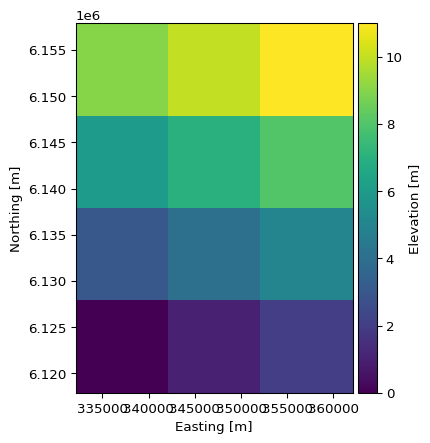

In [11]:
pgrid = mikeio.Grid2D(
    x0=337100.0, dx=10000.0, nx=3,
    y0=6122900.0, dy=10000.0, ny=4,
    projection="UTM-32",
)

pda = mikeio.DataArray(
    data=data,
    geometry=pgrid,
    time=pd.date_range("2020", periods=2, freq="D"),
    item=mikeio.ItemInfo("Elevation", mikeio.EUMType.Elevation),
)
pda.plot();

Cleanup:

In [12]:
import os
os.remove("example_geo.dfs2")